In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing --
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [ ]:
data=fetch_california_housing()
print(data)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Price")
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


Feature names:
| Feature    | Description       |
| ---------- | ----------------- |
| MedInc     | Median Income     |
| HouseAge   | House Age         |
| AveRooms   | Average Rooms     |
| AveBedrms  | Average Bedrooms  |
| Population | Population        |
| AveOccup   | Average Occupancy |
| Latitude   | Latitude          |
| Longitude  | Longitude         |

##Target: Median House Value


In [ ]:
y

,Price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
#Exercise: find out if X has any null values
X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


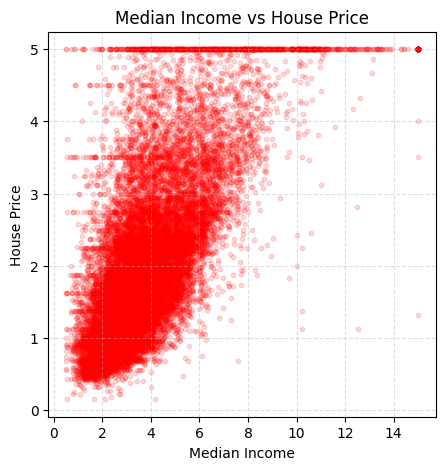

In [ ]:
#Visualization 1: Median Income vs housing price.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(X["MedInc"], y, alpha=0.15, s=10, color='red')
plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

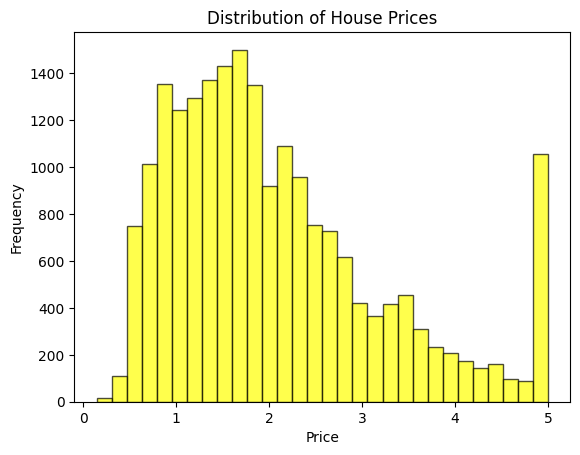

In [ ]:
#Visualize target price
plt.figure()
plt.hist(y, bins=30, color='yellow', edgecolor='black', alpha=0.7)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Visualization 3: Correlation Heatmap
X.corr() #Positive correlation, negative correlation, strong and weak correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


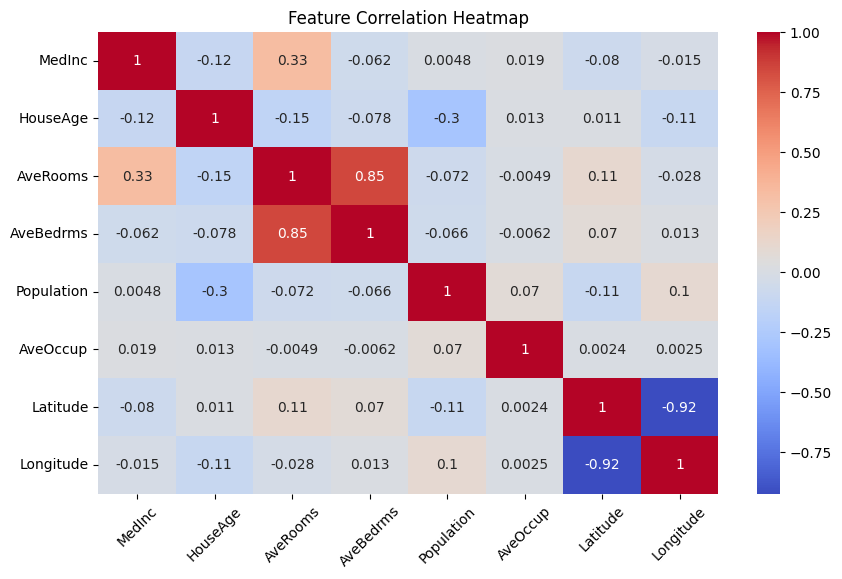

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

#Strong correlation-
#Weakest correlation


In [ ]:
#Train test split. Standard Scaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression() #Model Initialization
model.fit(X_train, y_train) #Model Training

LinearRegression()

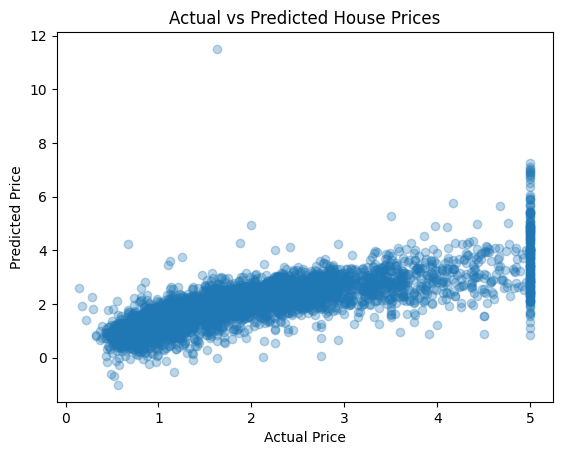

In [ ]:
y_pred = model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
X_single = X[["MedInc"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train_s)

y_pred_s = model_s.predict(X_test_s)

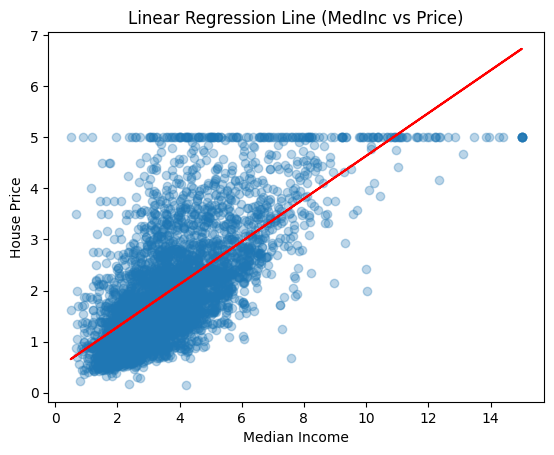

In [ ]:
plt.figure()
plt.scatter(X_test_s, y_test_s, alpha=0.3)

plt.plot(X_test_s, y_pred_s, color="red")
plt.title("Linear Regression Line (MedInc vs Price)")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

In [ ]:
# Evaluation metrics - MAE, MSE, RMSE, R2
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.5332001304956565
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2: 0.575787706032451


In [ ]:
#Range
''' MAE- 0 and infinity- Lower is better (0.1-0.5) is a good score
MSE - 0 and infinity- Lower is better, If it has larger values, means data has outliers.
RMSE- 0 Perfect, low- good model, high- Poor model
R2 score -(minus)infinity to 1 , closer to 1 the better , negative score means model is bad